<a href="https://colab.research.google.com/github/jwookkim0512/machinelearning-assignments/blob/main/%EA%B3%BC%EC%A0%9C_%EC%A0%9C%EC%B6%9C%EC%9A%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.tree import export_graphviz
import pydotplus
from IPython.display import Image

data = np.array([[0, 2, 1, 0, 0],
                [0, 2, 1, 1, 0],
                [1, 2, 1, 0, 1],
                [2, 1, 1, 0, 1],
                [2, 0, 0, 0, 1],
                [2, 0, 0, 1, 0],
                [1, 0, 0, 1, 1],
                [0, 1, 1, 0, 0],
                [0, 0, 0, 0, 1],
                [2, 1, 0, 0, 1],
                [0, 1, 0, 1, 1],
                [1, 1, 1, 1, 1],
                [1, 2, 0, 0, 1],
                [2, 1, 1, 1, 0]])
X = data[:,0:4]
y = data[:,4]

전체 데이터 엔트로피: 0.9403
Feature 0의 정보 이득: 0.2467
Feature 1의 정보 이득: 0.0292
Feature 2의 정보 이득: 0.1518
Feature 3의 정보 이득: 0.0481


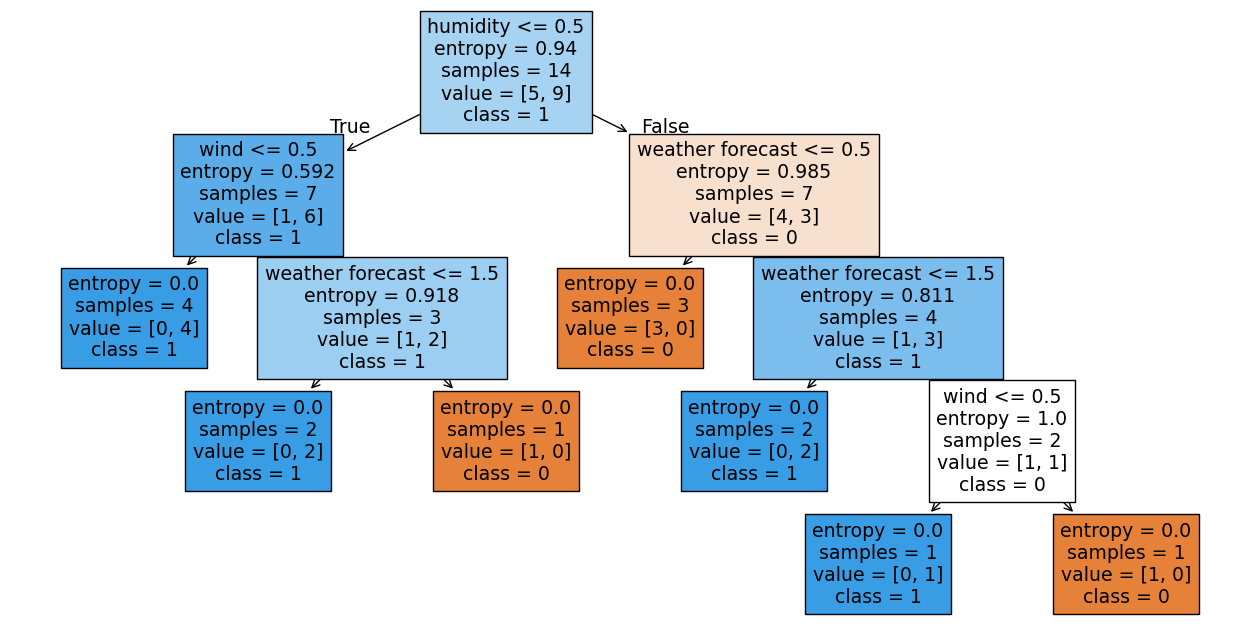

In [ ]:
# Information entropy 함수 정의
def entropy(y):
    # y의 고유값과 각각의 빈도수 계산
    values, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()  # pk
    # 엔트로피 계산
    return -np.sum(p * np.log2(p))

# 전체 데이터의 엔트로피 계산
total_entropy = entropy(y)
print(f"전체 데이터 엔트로피: {total_entropy:.4f}")

#  피처별(출석, 과제, 중간고사, 기말고사) 정보 이득(Information Gain) 계산
for feature_idx in range(X.shape[1]):
    feature_values = np.unique(X[:, feature_idx])
    feature_entropy = 0
    for value in feature_values:
        # 해당 값에 해당하는 데이터 인덱스
        idx = X[:, feature_idx] == value
        subset_y = y[idx]
        weight = len(subset_y) / len(y)
        subset_entropy = entropy(subset_y)
        feature_entropy += weight * subset_entropy
    info_gain = total_entropy - feature_entropy
    print(f"Feature {feature_idx}의 정보 이득: {info_gain:.4f}")
    # scikit-learn의 DecisionTreeClassifier를 엔트로피 기준으로 학습
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)
clf.fit(X,y)

# Decision Tree for binary classifier
plt.figure(figsize=(16,8))
tree.plot_tree(clf, feature_names=['weather forecast', 'temperature', 'humidity', 'wind'], class_names=['0', '1'], filled=True)
plt.show()

그렇기에 의사결정트리의 뿌리 노드는 원래 기상예보가 되어야 하는 것이 맞다. 그런데 기상예보는 0과 1과 2로 구성이 되어있어 날씨처럼 순서 없는 값에 숫자(0,1,2)를 쓰면 모델이 그걸 숫자처럼 비교해서 엉뚱한 분할을 하게 된다. 해결책을 알아본 결과 one hot encoding을 통해서 기상예보를 One-Hot Encoding으로 변환해서
각 상태(맑음, 흐림, 비)를 독립적인 열(feature)로 나누어 주면 된다.

Total entropy: 0.9403
Feature 'Sunny' Info Gain: 0.1022
Feature 'Overcast' Info Gain: 0.2260
Feature 'Rain' Info Gain: 0.0032
Feature 'Temperature' Info Gain: 0.0292
Feature 'Humidity' Info Gain: 0.1518
Feature 'Wind' Info Gain: 0.0481


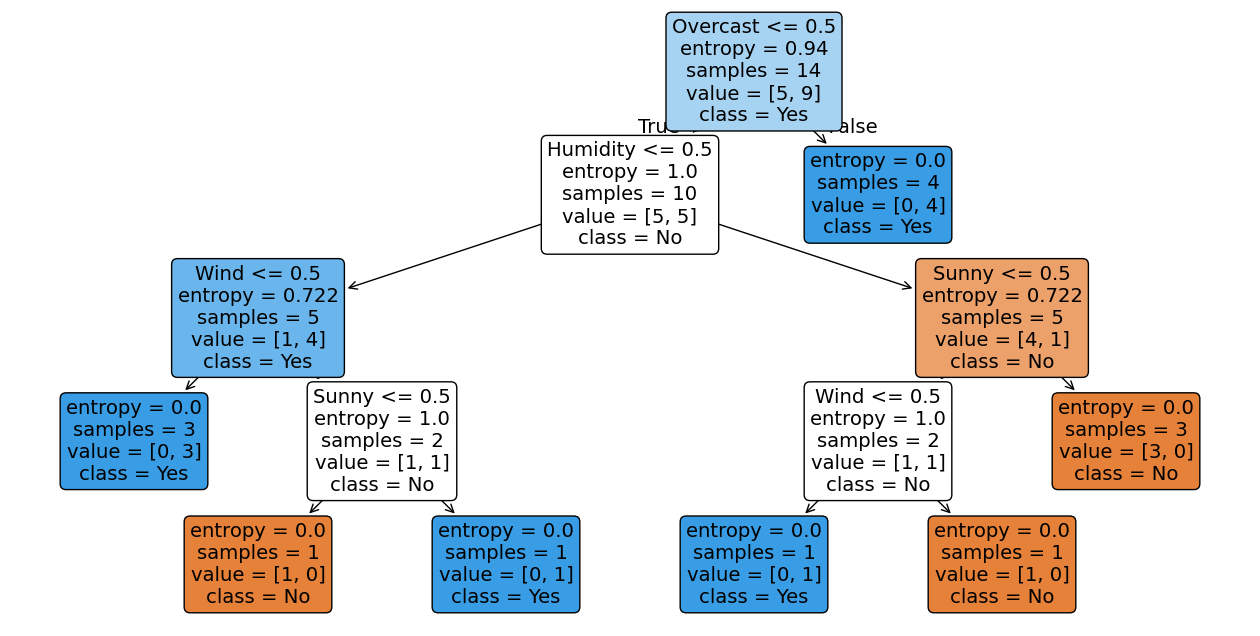

In [ ]:
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

# 데이터 정의
data = np.array([
    [0, 2, 1, 0, 0],
    [0, 2, 1, 1, 0],
    [1, 2, 1, 0, 1],
    [2, 1, 1, 0, 1],
    [2, 0, 0, 0, 1],
    [2, 0, 0, 1, 0],
    [1, 0, 0, 1, 1],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 1],
    [2, 1, 0, 0, 1],
    [0, 1, 0, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 2, 0, 0, 1],
    [2, 1, 1, 1, 0]
])

X_raw = data[:, 0:4]
y = data[:, 4]

# ✅ One-Hot Encoding (기상예보 열만)
encoder = OneHotEncoder(sparse_output=False)
weather_encoded = encoder.fit_transform(X_raw[:, [0]])
X = np.hstack((weather_encoded, X_raw[:, 1:]))

# 피처 이름
feature_names = ['Sunny', 'Overcast', 'Rain', 'Temperature', 'Humidity', 'Wind']

# ✅ 엔트로피 함수
def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p))

# ✅ 정보이득 계산
total_entropy = entropy(y)
print(f"Total entropy: {total_entropy:.4f}")

for i in range(X.shape[1]):
    values = np.unique(X[:, i])
    f_entropy = 0
    for v in values:
        idx = X[:, i] == v
        subset = y[idx]
        weight = len(subset) / len(y)
        f_entropy += weight * entropy(subset)
    info_gain = total_entropy - f_entropy
    print(f"Feature '{feature_names[i]}' Info Gain: {info_gain:.4f}")

# ✅ 결정트리 학습
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)
clf.fit(X, y)

# ✅ 트리 시각화
plt.figure(figsize=(16, 8))
tree.plot_tree(
    clf,
    feature_names=feature_names,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)
plt.show()


Total entropy: 0.9403
Feature 'Sunny' Info Gain: 0.1022
Feature 'Overcast' Info Gain: 0.2260
Feature 'Rain' Info Gain: 0.0032
Feature 'Temperature' Info Gain: 0.0292
Feature 'Humidity' Info Gain: 0.1518
Feature 'Wind' Info Gain: 0.0481


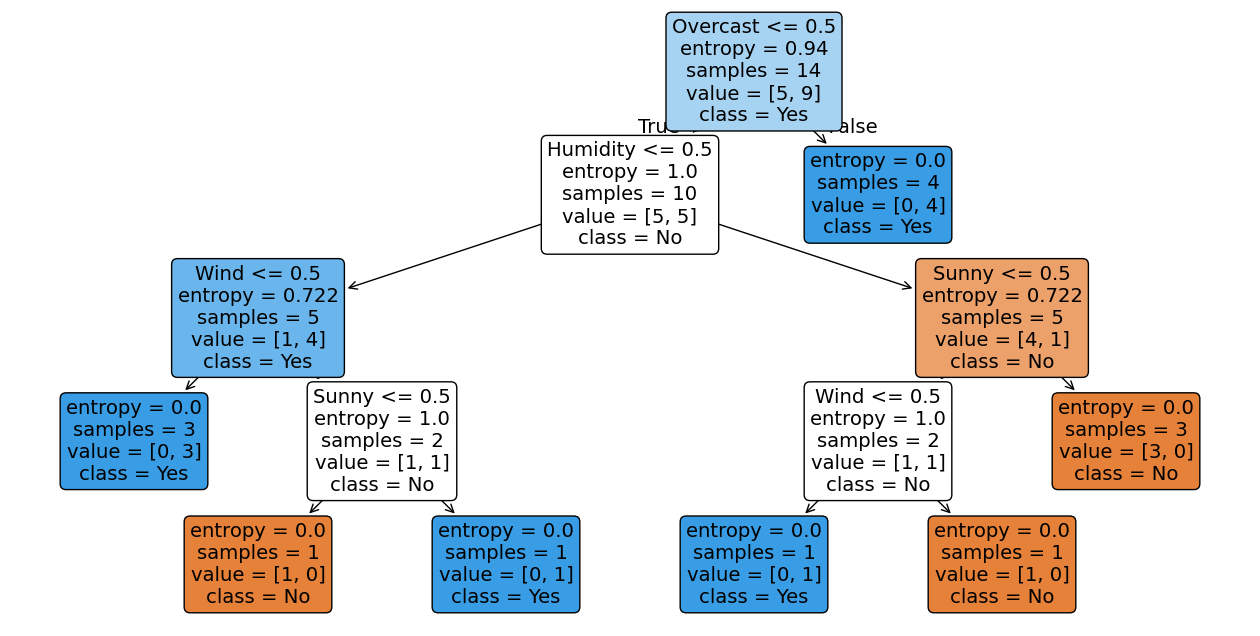

In [ ]:
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt

# 맑음(1,0,0), 흐림(0,1,0), 비(0,0,1) + 온도 + 습도 + 바람 + 결과
data = np.array([
    [1,0,0, 2,1,0, 0],
    [1,0,0, 2,1,1, 0],
    [0,1,0, 2,1,0, 1],
    [0,0,1, 1,1,0, 1],
    [0,0,1, 0,0,0, 1],
    [0,0,1, 0,0,1, 0],
    [0,1,0, 0,0,1, 1],
    [1,0,0, 1,1,0, 0],
    [1,0,0, 0,0,0, 1],
    [0,0,1, 1,0,0, 1],
    [1,0,0, 1,0,1, 1],
    [0,1,0, 1,1,1, 1],
    [0,1,0, 2,0,0, 1],
    [0,0,1, 1,1,1, 0]
])

# X: 피처, y: 정답
X = data[:, 0:6]
y = data[:, 6]

def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p))

# ✅ 전체 엔트로피 및 각 피처별 정보이득 계산
total_entropy = entropy(y)
print(f"Total entropy: {total_entropy:.4f}")

for feature_idx in range(X.shape[1]):
    feature_values = np.unique(X[:, feature_idx])
    feature_entropy = 0
    for value in feature_values:
        idx = X[:, feature_idx] == value
        subset_y = y[idx]
        weight = len(subset_y) / len(y)
        feature_entropy += weight * entropy(subset_y)
    info_gain = total_entropy - feature_entropy
    print(f"Feature '{feature_names[feature_idx]}' Info Gain: {info_gain:.4f}")

# 피처 이름 정의
feature_names = ['Sunny', 'Overcast', 'Rain', 'Temperature', 'Humidity', 'Wind']

# 모델 학습
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)
clf.fit(X, y)

# 트리 시각화
plt.figure(figsize=(16, 8))
tree.plot_tree(
    clf,
    feature_names=feature_names,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
)
plt.show()


<ipython-input-15-a5e913a9e2f8>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace({'F': 2, 'M': 1})
<ipython-input-15-a5e913a9e2f8>:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['BP'] = df['BP'].replace({'HIGH': 2, 'LOW': 1, 'NORMAL': 0})
<ipython-input-15-a5e913a9e2f8>:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `p

정확도 (Age, Na_to_K 제외): 0.5750


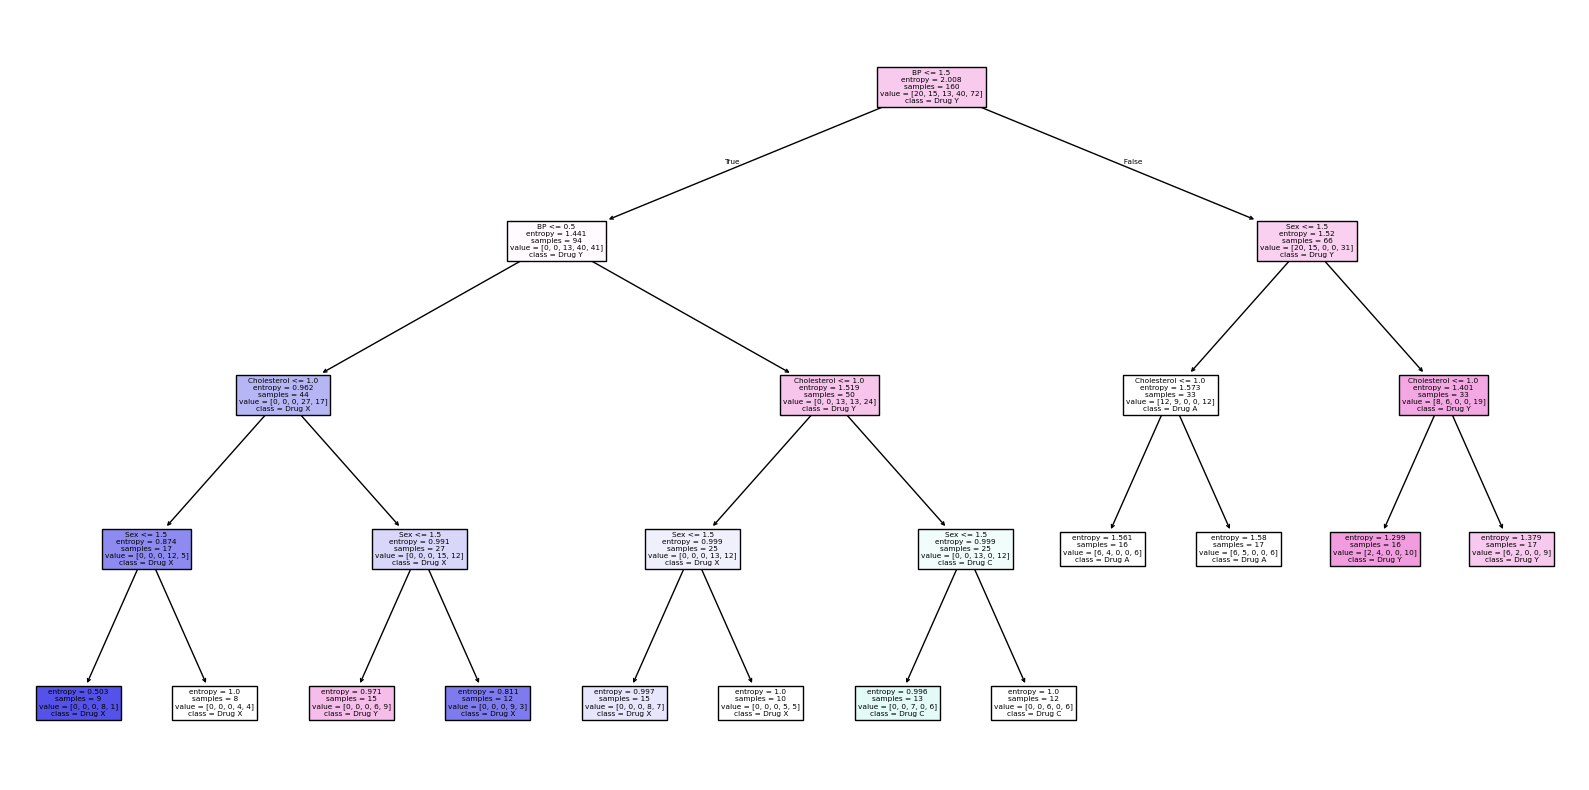

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score  # ← 정확도 함수 반드시 추가!!

# CSV 파일 불러오기
df = pd.read_csv("/content/drug200.csv")  # 경로는 작업 환경에 맞게 조정

# 값 변환 (문자형 → 숫자형)
df['Sex'] = df['Sex'].replace({'F': 2, 'M': 1})
df['BP'] = df['BP'].replace({'HIGH': 2, 'LOW': 1, 'NORMAL': 0})
df['Cholesterol'] = df['Cholesterol'].replace({'HIGH': 2, 'NORMAL': 0})
df['Drug'] = df['Drug'].replace({'drugA': 1, 'drugB': 2, 'drugC': 3, 'drugX': 4, 'drugY': 5})

# 사용할 피처 선택 (Age, Na_to_K 제외)
X = df[['Sex', 'BP', 'Cholesterol']]
y = df['Drug']

# 학습용/테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 결정 트리 모델 학습
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4)
clf.fit(X_train, y_train)

# 예측 및 정확도 출력
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 (Age, Na_to_K 제외): {accuracy:.4f}")

# 트리 시각화
plt.figure(figsize=(16, 8))
plot_tree(clf,
          feature_names=X.columns,
          class_names=['Drug A', 'Drug B', 'Drug C', 'Drug X', 'Drug Y'],
          filled=True)
plt.tight_layout()
plt.show()


정확도가 낮은 이유는 교수님이 요청하신 나트륨과 나이를 제외하였기 때문이다 하단 코드는 모두 추가한 코드이다.

<ipython-input-16-4faa8a99e017>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace({'F': 2, 'M': 1})
<ipython-input-16-4faa8a99e017>:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['BP'] = df['BP'].replace({'HIGH': 2, 'LOW': 1, 'NORMAL': 0})
<ipython-input-16-4faa8a99e017>:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `p

정확도 (Age, Na_to_K 포함): 1.0000


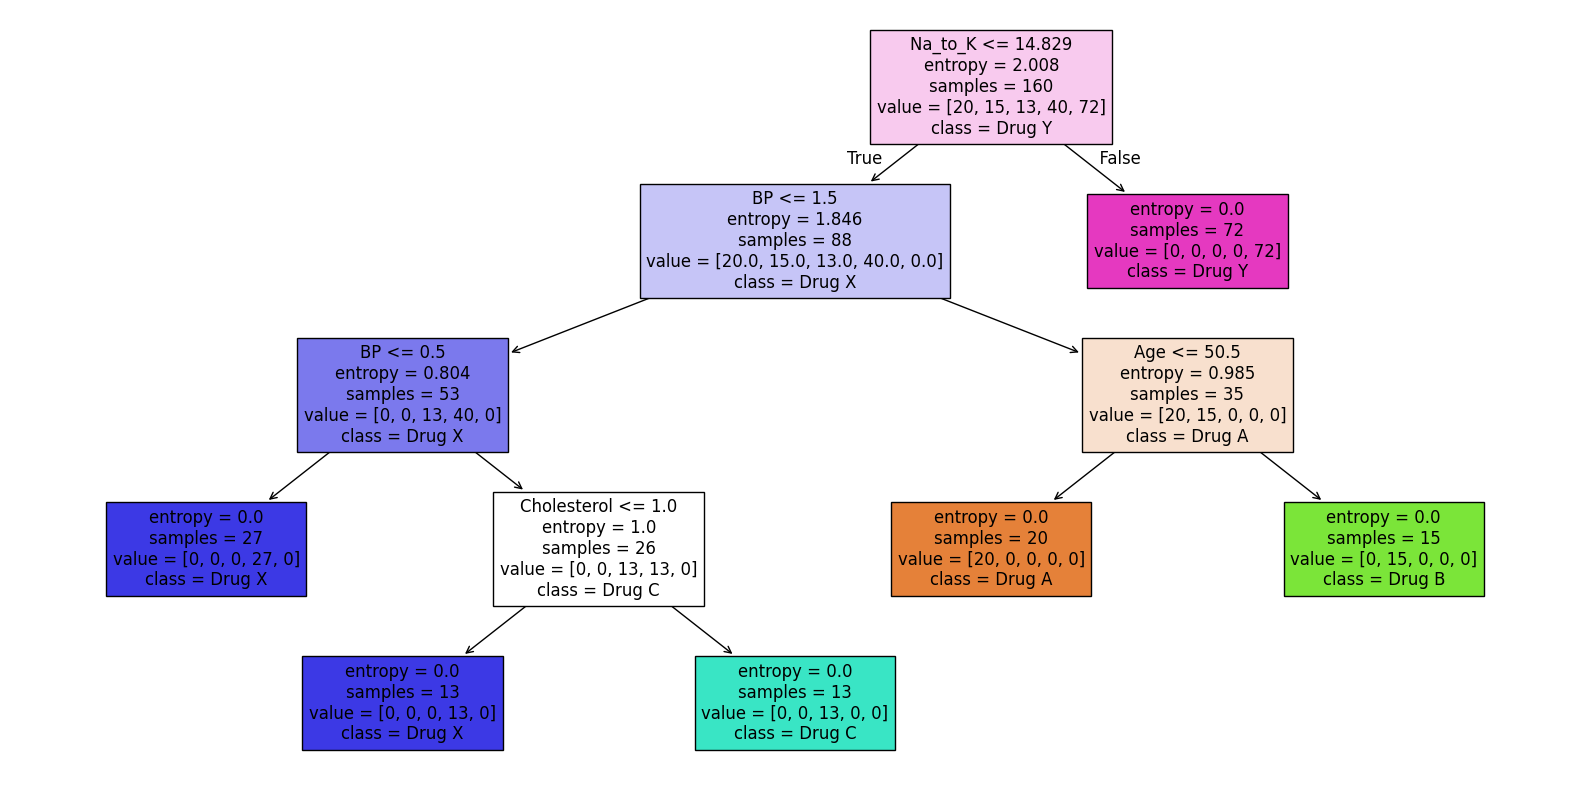

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# CSV 파일 불러오기
df = pd.read_csv("/content/drug200.csv")  # 경로는 작업 환경에 맞게 수정

# 값 변환
df['Sex'] = df['Sex'].replace({'F': 2, 'M': 1})
df['BP'] = df['BP'].replace({'HIGH': 2, 'LOW': 1, 'NORMAL': 0})
df['Cholesterol'] = df['Cholesterol'].replace({'HIGH': 2, 'NORMAL': 0})
df['Drug'] = df['Drug'].replace({'drugA': 1, 'drugB': 2, 'drugC': 3, 'drugX': 4, 'drugY': 5})

# ❗ Age와 Na_to_K 포함한 입력 데이터 설정
X = df[['Age', 'Na_to_K', 'Sex', 'BP', 'Cholesterol']]
y = df['Drug']

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 결정 트리 학습
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4)
clf.fit(X_train, y_train)

# 예측 및 정확도 출력
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"정확도 (Age, Na_to_K 포함): {accuracy:.4f}")

# 트리 시각화
plt.figure(figsize=(16, 8))
plot_tree(clf,
          feature_names=X.columns,
          class_names=['Drug A', 'Drug B', 'Drug C', 'Drug X', 'Drug Y'],
          filled=True)
plt.tight_layout()
plt.show()